# Imports

In [1]:
from pathlib import Path
import pypff
from matplotlib import pyplot as plt
import numpy as np

import heap

## Read Test Data

In [2]:
data_file = Path("../test_data/20251020/Gattini/pff/").resolve()
data_path = Path(data_file).resolve()
if not data_path.exists():
    raise FileNotFoundError(f"Data directory not found: {data_path}")
else:
    print(data_path)

/Users/nik/Documents/PANOSETI/PANOSETI-High-Energy-Analysis-Pipeline/test_data/20251020/Gattini/pff


In [3]:
# read ph1024 data file
file = str(data_path / "start_2025-10-20T06:50:55Z.dp_ph1024.bpp_2.module_254.seqno_0.pff")
pff = pypff.io.datapff(file)
data, metadata = pff.readpff(metadata=True)

In [4]:
data

array([[20, 12, 12, ..., 16, 13,  6],
       [15, 17, 11, ..., 18, 17,  8],
       [ 9, 15,  4, ..., 20, 32, 15],
       ...,
       [18, 38, 39, ..., 28, 23, 15],
       [23, 34, 31, ..., 18, 27, 27],
       [18, 24, 45, ..., 27, 24, 28]], shape=(24330, 1024), dtype=int16)

In [5]:
# How many events do we have?
len(data)

24330

In [6]:
# Check accessing single pixel for a single event
print(data[0][2])

12


## Plot the data

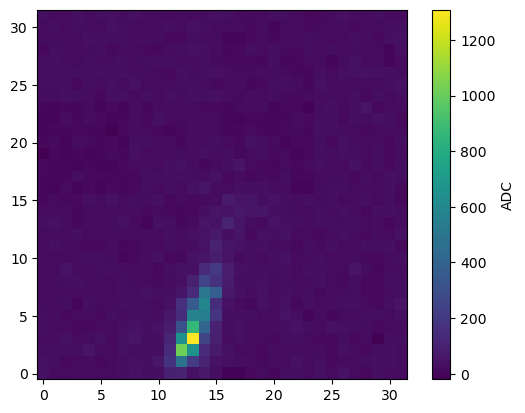

In [7]:
# get quabo_num from metadata, so that we know the packet is from which Quabo
#quabo_0 = metadata['quabo_0']

# Plot this event
skip = 4321

fig = plt.figure()
matrix = data[skip].reshape((32, 32))
plt.imshow(matrix, origin='lower')
plt.colorbar(label='ADC')
plt.show()

# Make Pedestals

### Make a pedestal distribution for a single pixel

Mean:  24.24780106863954
Std:   33.99980598053801
Updated Mean:  23.71590161237249
Updated Std:   9.048175358221316


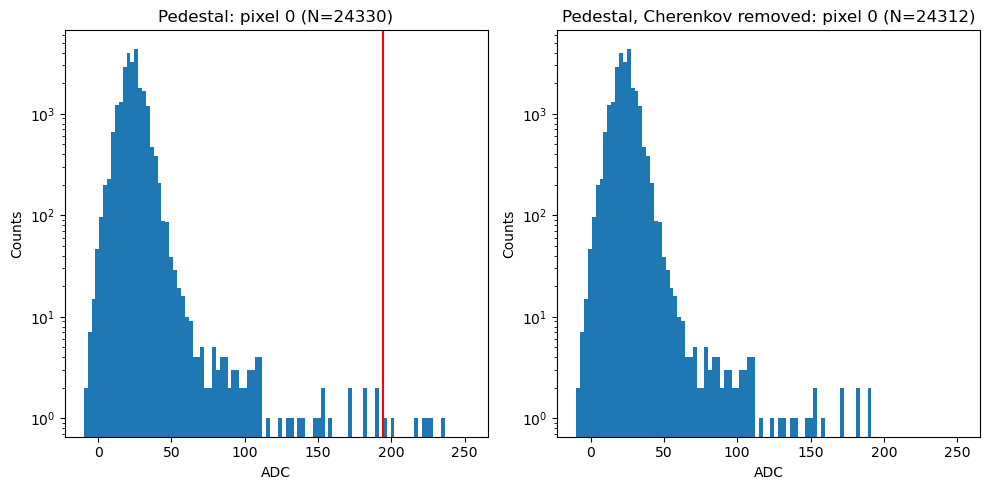

In [8]:
heap.make_pedestals.plot_distribution(data)

### Now make pedestal distributions for all pixels and get mean and std

In [16]:
pedestal, pedestal_variance = heap.make_pedestals.make_pedestal_image(data)

### Plot pedestals

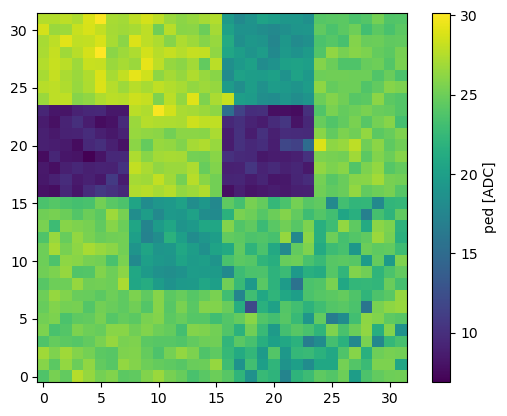

In [18]:
fig = plt.figure()
ped_image = pedestal.reshape((32, 32))
plt.imshow(ped_image, origin='lower')
plt.colorbar(label='ped [ADC]')
plt.show()

### Plot ped vars

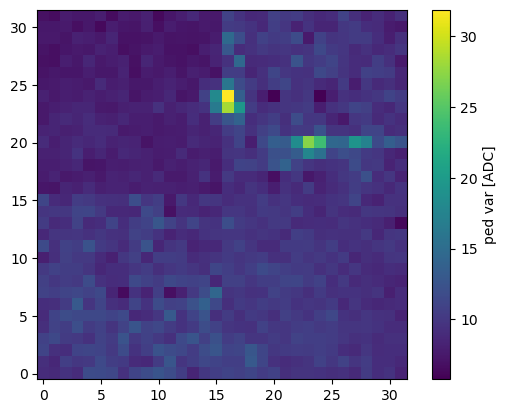

In [19]:
fig = plt.figure()
ped_var_image = pedestal_variance.reshape((32, 32))
plt.imshow(ped_var_image, origin='lower')
plt.colorbar(label='ped var [ADC]')